# Анализ датасета Dataset2 (Российский ангиографический датасет стенозов)

Формат имён файлов: `{prefix}_{patient}_{sequence}_{frame}_bmp_jpg.rf.{hash}.jpg`
- **Пациент**: первые два токена (e.g. `14_002`)
- **Последовательность**: первые три токена (e.g. `14_002_5`)
- **Кадр**: четвёртый токен (e.g. `0016`)
- **Стеноз**: определяется по наличию непустого label-файла

## 1. Импорт библиотек и настройка путей

In [1]:
import os
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATASET_DIR = Path("/home/dsa/stenosis/data/dataset2_base")
IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"

print(f"Images dir: {IMAGES_DIR}")
print(f"Labels dir: {LABELS_DIR}")
print(f"Exists: images={IMAGES_DIR.exists()}, labels={LABELS_DIR.exists()}")

Images dir: /home/dsa/stenosis/data/dataset2_base/images
Labels dir: /home/dsa/stenosis/data/dataset2_base/labels
Exists: images=True, labels=True


## 2. Сканирование структуры директории и примеры имён файлов

In [2]:
image_files = sorted([f.name for f in IMAGES_DIR.iterdir() if f.suffix in ('.jpg', '.jpeg', '.png')])
label_files = sorted([f.name for f in LABELS_DIR.iterdir() if f.suffix == '.txt' and ':sec' not in f.name])

print(f"Всего изображений: {len(image_files)}")
print(f"Всего label-файлов: {len(label_files)}")
print(f"\nПримеры имён изображений:")
for f in image_files[:5]:
    print(f"  {f}")
print(f"\nПримеры имён меток:")
for f in label_files[:5]:
    print(f"  {f}")

Всего изображений: 8323
Всего label-файлов: 8323

Примеры имён изображений:
  14_002_5_0016_bmp_jpg.rf.b7a04bce00b1260d1bdbf8b302d3dd13.jpg
  14_002_5_0018_bmp_jpg.rf.465c60ebf738bc26186e9a47e2c523ac.jpg
  14_002_5_0019_bmp_jpg.rf.90ee9f0e68f49744f93210fc0453638a.jpg
  14_002_5_0020_bmp_jpg.rf.98aa8b3f5633862fd59e70d16fe26b64.jpg
  14_002_5_0021_bmp_jpg.rf.3567dac32085d712db9ed0b2de3ac81d.jpg

Примеры имён меток:
  14_002_5_0016_bmp_jpg.rf.b7a04bce00b1260d1bdbf8b302d3dd13.txt
  14_002_5_0018_bmp_jpg.rf.465c60ebf738bc26186e9a47e2c523ac.txt
  14_002_5_0019_bmp_jpg.rf.90ee9f0e68f49744f93210fc0453638a.txt
  14_002_5_0020_bmp_jpg.rf.98aa8b3f5633862fd59e70d16fe26b64.txt
  14_002_5_0021_bmp_jpg.rf.3567dac32085d712db9ed0b2de3ac81d.txt


## 3. Парсинг имён файлов и создание DataFrame

In [3]:
records = []

for img_name in image_files:
    # Имя до .rf.{hash}.jpg — базовое имя кадра
    base_name = img_name.split('.rf.')[0]  # e.g. "14_002_5_0016_bmp_jpg"
    parts = base_name.split('_')
    # parts: ['14', '002', '5', '0016', 'bmp', 'jpg']
    
    patient_id = f"{parts[0]}_{parts[1]}"       # e.g. "14_002"
    sequence_id = f"{parts[0]}_{parts[1]}_{parts[2]}"  # e.g. "14_002_5"
    frame_num = parts[3]                          # e.g. "0016"
    
    # Проверяем наличие и содержимое label-файла
    label_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt')
    label_path = LABELS_DIR / label_name
    
    has_label = label_path.exists()
    has_stenosis = False
    num_bboxes = 0
    if has_label:
        content = label_path.read_text().strip()
        if content:
            has_stenosis = True
            num_bboxes = len(content.splitlines())
    
    records.append({
        'image_name': img_name,
        'base_name': base_name,
        'patient_id': patient_id,
        'sequence_id': sequence_id,
        'frame': frame_num,
        'has_label_file': has_label,
        'has_stenosis': has_stenosis,
        'num_bboxes': num_bboxes,
    })

df = pd.DataFrame(records)
print(f"DataFrame shape: {df.shape}")
df.head(10)

DataFrame shape: (8323, 8)


,image_name,base_name,patient_id,sequence_id,frame,has_label_file,has_stenosis,num_bboxes
0,14_002_5_0016_bmp_jpg.rf.b7a04bce00b1260d1bdbf...,14_002_5_0016_bmp_jpg,14_002,14_002_5,0016,True,True,1
1,14_002_5_0018_bmp_jpg.rf.465c60ebf738bc26186e9...,14_002_5_0018_bmp_jpg,14_002,14_002_5,0018,True,True,1
2,14_002_5_0019_bmp_jpg.rf.90ee9f0e68f49744f9321...,14_002_5_0019_bmp_jpg,14_002,14_002_5,0019,True,True,1
3,14_002_5_0020_bmp_jpg.rf.98aa8b3f5633862fd59e7...,14_002_5_0020_bmp_jpg,14_002,14_002_5,0020,True,True,1
4,14_002_5_0021_bmp_jpg.rf.3567dac32085d712db9ed...,14_002_5_0021_bmp_jpg,14_002,14_002_5,0021,True,True,1
5,14_002_5_0023_bmp_jpg.rf.13fccf9e57f4f443282b5...,14_002_5_0023_bmp_jpg,14_002,14_002_5,0023,True,True,1
6,14_002_5_0024_bmp_jpg.rf.10ecfe3a709cf000498fd...,14_002_5_0024_bmp_jpg,14_002,14_002_5,0024,True,True,1
7,14_002_5_0025_bmp_jpg.rf.c5697b208b6d354b1adaf...,14_002_5_0025_bmp_jpg,14_002,14_002_5,0025,True,True,1
8,14_002_5_0026_bmp_jpg.rf.9e2ddc33d47911655e80a...,14_002_5_0026_bmp_jpg,14_002,14_002_5,0026,True,True,1
9,14_002_5_0027_bmp_jpg.rf.80ff4ba08dc77e337ee5a...,14_002_5_0027_bmp_jpg,14_002,14_002_5,0027,True,True,1


## 4. Общая статистика: последовательности, кадры, пациенты

In [4]:
n_patients = df['patient_id'].unique()

In [5]:
n_patients

array(['14_002', '14_003', '14_006', '14_007', '14_010', '14_012',
       '14_014', '14_015', '14_016', '14_017', '14_018', '14_019',
       '14_021', '14_022', '14_023', '14_024', '14_026', '14_028',
       '14_029', '14_031', '14_032', '14_033', '14_034', '14_039',
       '14_040', '14_042', '14_044', '14_046', '14_048', '14_049',
       '14_050', '14_051', '14_052', '14_053', '14_055', '14_057',
       '14_058', '14_059', '14_062', '14_064', '14_066', '14_067',
       '14_068', '14_069', '14_070', '14_073', '14_075', '14_076',
       '14_077', '14_080', '14_081', '14_083', '14_084', '14_085',
       '14_087', '14_088', '14_091', '14_092', '14_094', '14_095',
       '14_096', '14_097', '14_098', '14_099'], dtype=object)

In [6]:
n_patients = df['patient_id'].nunique()
n_sequences = df['sequence_id'].nunique()
n_frames = len(df)

print(f"{'='*50}")
print(f"  Общая статистика датасета Dataset2")
print(f"{'='*50}")
print(f"  Пациентов:          {n_patients}")
print(f"  Последовательностей: {n_sequences}")
print(f"  Кадров (изображений): {n_frames}")
print(f"{'='*50}")

# Кадров на последовательность
frames_per_seq = df.groupby('sequence_id').size()
print(f"\nКадров на последовательность:")
print(f"  min:    {frames_per_seq.min()}")
print(f"  max:    {frames_per_seq.max()}")
print(f"  mean:   {frames_per_seq.mean():.1f}")
print(f"  median: {frames_per_seq.median():.1f}")

# Последовательностей на пациента
seqs_per_patient = df.groupby('patient_id')['sequence_id'].nunique()
print(f"\nПоследовательностей на пациента:")
print(f"  min:    {seqs_per_patient.min()}")
print(f"  max:    {seqs_per_patient.max()}")
print(f"  mean:   {seqs_per_patient.mean():.1f}")
print(f"  median: {seqs_per_patient.median():.1f}")

  Общая статистика датасета Dataset2
  Пациентов:          64
  Последовательностей: 214
  Кадров (изображений): 8323

Кадров на последовательность:
  min:    7
  max:    121
  mean:   38.9
  median: 36.0

Последовательностей на пациента:
  min:    1
  max:    15
  mean:   3.3
  median: 3.0


## 5. Классификация последовательностей по наличию стеноза

Последовательность считается **со стенозом**, если хотя бы один кадр в ней имеет непустой label-файл (т.е. размечен bbox стеноза).

In [7]:
# Классификация кадров
n_frames_with_stenosis = df['has_stenosis'].sum()
n_frames_without_stenosis = len(df) - n_frames_with_stenosis
print(f"Кадры со стенозом:   {n_frames_with_stenosis} ({n_frames_with_stenosis/len(df)*100:.1f}%)")
print(f"Кадры без стеноза:   {n_frames_without_stenosis} ({n_frames_without_stenosis/len(df)*100:.1f}%)")

# Классификация последовательностей
seq_stenosis = df.groupby('sequence_id')['has_stenosis'].any()
n_seq_with = seq_stenosis.sum()
n_seq_without = len(seq_stenosis) - n_seq_with
print(f"\nПоследовательности со стенозом:   {n_seq_with} ({n_seq_with/len(seq_stenosis)*100:.1f}%)")
print(f"Последовательности без стеноза:   {n_seq_without} ({n_seq_without/len(seq_stenosis)*100:.1f}%)")

# Доля кадров со стенозом внутри каждой последовательности
seq_stats = df.groupby('sequence_id').agg(
    total_frames=('has_stenosis', 'size'),
    stenosis_frames=('has_stenosis', 'sum'),
    total_bboxes=('num_bboxes', 'sum'),
    patient=('patient_id', 'first'),
).reset_index()
seq_stats['stenosis_ratio'] = seq_stats['stenosis_frames'] / seq_stats['total_frames']
seq_stats['has_any_stenosis'] = seq_stats['stenosis_frames'] > 0

print(f"\nДоля кадров со стенозом в последовательностях (у тех, где есть стеноз):")
with_stenosis = seq_stats[seq_stats['has_any_stenosis']]
print(f"  min:    {with_stenosis['stenosis_ratio'].min():.1%}")
print(f"  max:    {with_stenosis['stenosis_ratio'].max():.1%}")
print(f"  mean:   {with_stenosis['stenosis_ratio'].mean():.1%}")
print(f"  median: {with_stenosis['stenosis_ratio'].median():.1%}")

seq_stats.head(15)

Кадры со стенозом:   8323 (100.0%)
Кадры без стеноза:   0 (0.0%)

Последовательности со стенозом:   214 (100.0%)
Последовательности без стеноза:   0 (0.0%)

Доля кадров со стенозом в последовательностях (у тех, где есть стеноз):
  min:    100.0%
  max:    100.0%
  mean:   100.0%
  median: 100.0%


,sequence_id,total_frames,stenosis_frames,total_bboxes,patient,stenosis_ratio,has_any_stenosis
0,14_002_5,31,31,31,14_002,1.0,True
1,14_002_8,20,20,20,14_002,1.0,True
2,14_003_1,27,27,27,14_003,1.0,True
3,14_003_2,17,17,17,14_003,1.0,True
4,14_006_1,113,113,113,14_006,1.0,True
5,14_007_10,63,63,63,14_007,1.0,True
6,14_007_3,67,67,67,14_007,1.0,True
7,14_007_5,88,88,88,14_007,1.0,True
8,14_007_6,67,67,67,14_007,1.0,True
9,14_007_8,89,89,89,14_007,1.0,True


## 6. Анализ распределения по пациентам

In [8]:
patient_stats = seq_stats.groupby('patient').agg(
    total_sequences=('sequence_id', 'count'),
    sequences_with_stenosis=('has_any_stenosis', 'sum'),
    total_frames=('total_frames', 'sum'),
    stenosis_frames=('stenosis_frames', 'sum'),
    total_bboxes=('total_bboxes', 'sum'),
).reset_index()
patient_stats['sequences_without_stenosis'] = patient_stats['total_sequences'] - patient_stats['sequences_with_stenosis']
patient_stats['patient_has_stenosis'] = patient_stats['sequences_with_stenosis'] > 0

n_patients_with = patient_stats['patient_has_stenosis'].sum()
n_patients_without = len(patient_stats) - n_patients_with

print(f"Пациенты со стенозом:   {n_patients_with} ({n_patients_with/len(patient_stats)*100:.1f}%)")
print(f"Пациенты без стеноза:   {n_patients_without} ({n_patients_without/len(patient_stats)*100:.1f}%)")
print(f"\nСводная таблица по пациентам:")
print(patient_stats.to_string(index=False))

Пациенты со стенозом:   64 (100.0%)
Пациенты без стеноза:   0 (0.0%)

Сводная таблица по пациентам:
patient  total_sequences  sequences_with_stenosis  total_frames  stenosis_frames  total_bboxes  sequences_without_stenosis  patient_has_stenosis
 14_002                2                        2            51               51            51                           0                  True
 14_003                2                        2            44               44            44                           0                  True
 14_006                1                        1           113              113           113                           0                  True
 14_007                5                        5           374              374           374                           0                  True
 14_010                2                        2            82               82            82                           0                  True
 14_012                2      

## 7. Визуализация статистики датасета

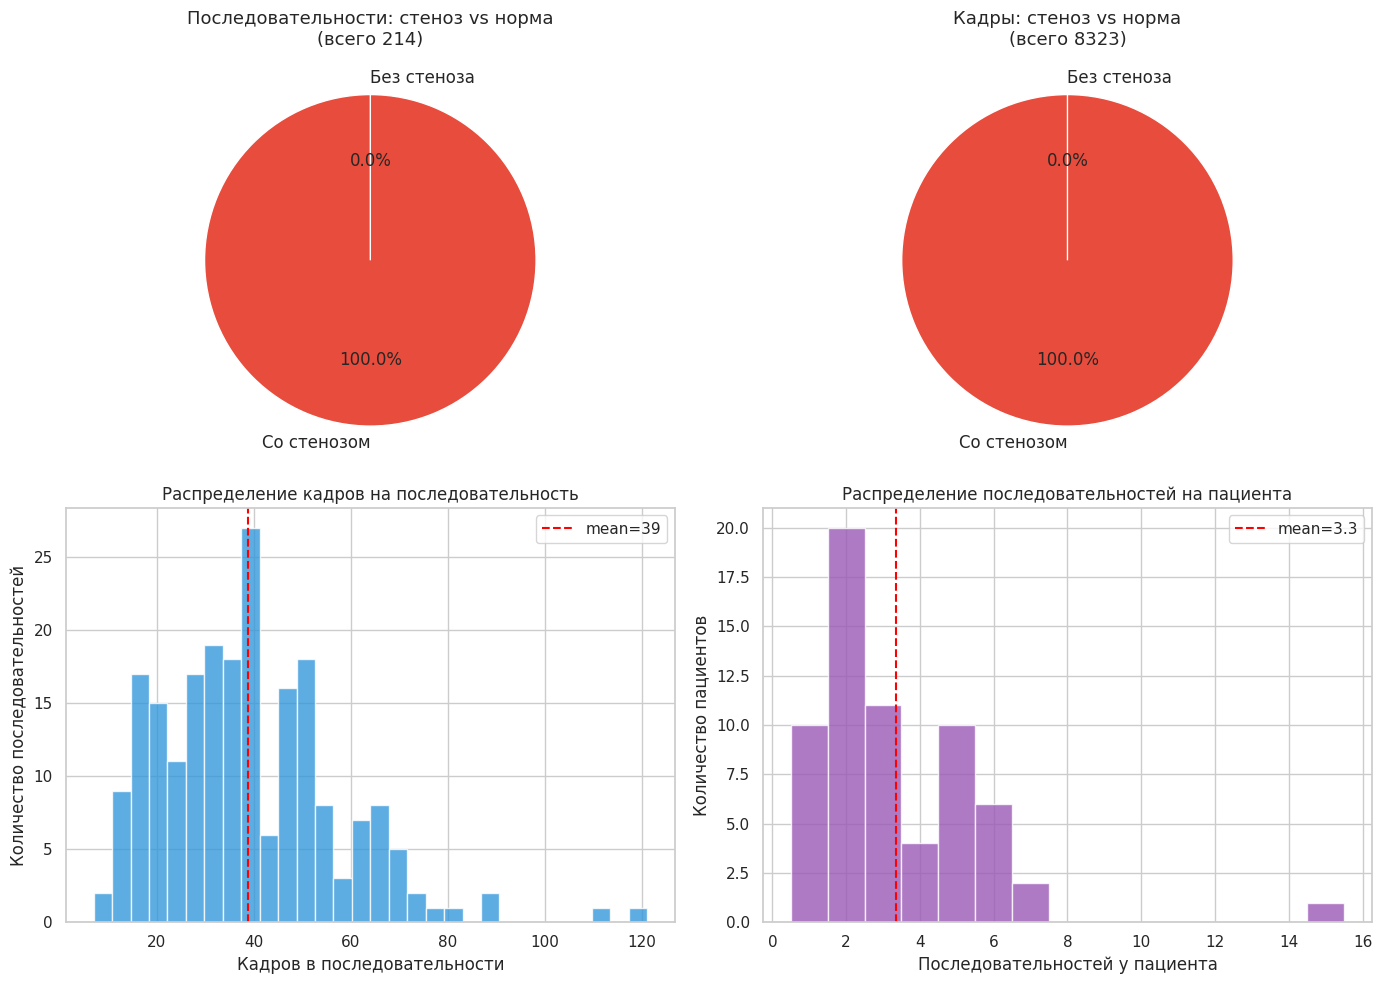

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Pie chart: последовательности со стенозом vs без
ax = axes[0, 0]
labels_pie = ['Со стенозом', 'Без стеноза']
sizes = [n_seq_with, n_seq_without]
colors_pie = ['#e74c3c', '#2ecc71']
ax.pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors_pie, startangle=90, textprops={'fontsize': 12})
ax.set_title(f'Последовательности: стеноз vs норма\n(всего {n_sequences})', fontsize=13)

# 2. Pie chart: кадры со стенозом vs без
ax = axes[0, 1]
sizes2 = [n_frames_with_stenosis, n_frames_without_stenosis]
ax.pie(sizes2, labels=labels_pie, autopct='%1.1f%%', colors=colors_pie, startangle=90, textprops={'fontsize': 12})
ax.set_title(f'Кадры: стеноз vs норма\n(всего {n_frames})', fontsize=13)

# 3. Гистограмма: кадров на последовательность
ax = axes[1, 0]
ax.hist(frames_per_seq.values, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
ax.set_xlabel('Кадров в последовательности')
ax.set_ylabel('Количество последовательностей')
ax.set_title('Распределение кадров на последовательность')
ax.axvline(frames_per_seq.mean(), color='red', linestyle='--', label=f'mean={frames_per_seq.mean():.0f}')
ax.legend()

# 4. Гистограмма: последовательностей на пациента
ax = axes[1, 1]
ax.hist(seqs_per_patient.values, bins=range(1, seqs_per_patient.max() + 2), color='#9b59b6', edgecolor='white', alpha=0.8, align='left')
ax.set_xlabel('Последовательностей у пациента')
ax.set_ylabel('Количество пациентов')
ax.set_title('Распределение последовательностей на пациента')
ax.axvline(seqs_per_patient.mean(), color='red', linestyle='--', label=f'mean={seqs_per_patient.mean():.1f}')
ax.legend()

plt.tight_layout()
plt.show()

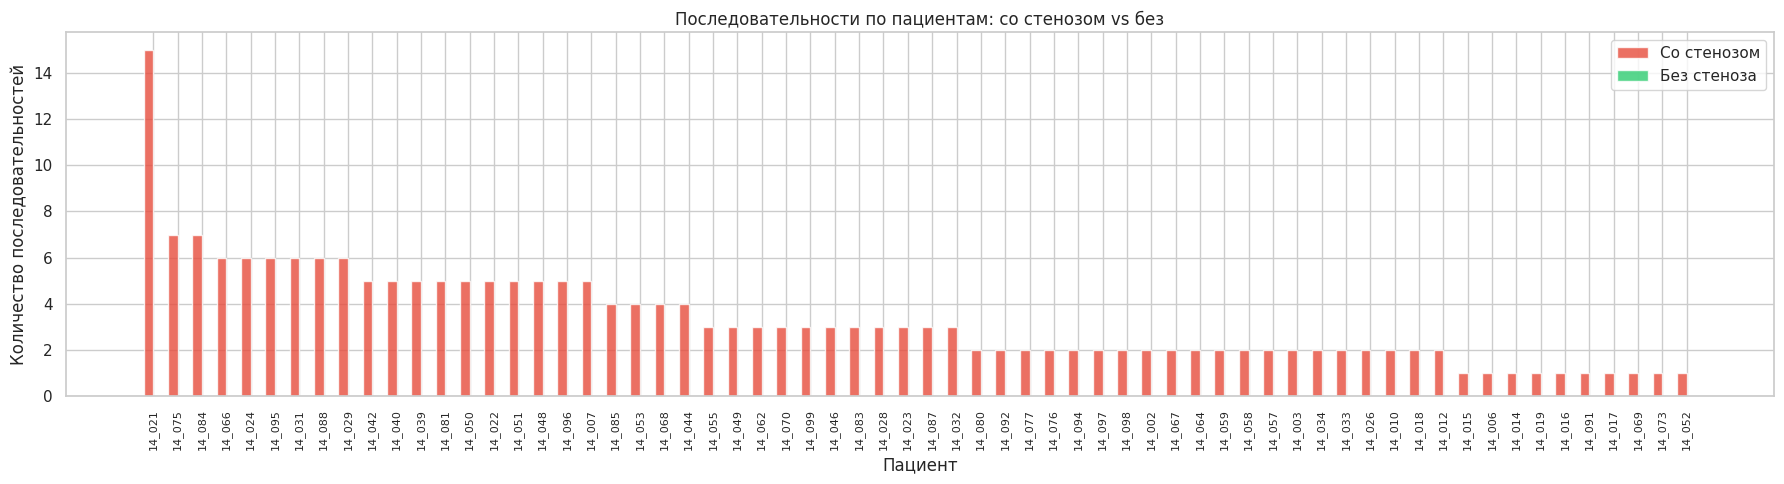

In [10]:
# Столбчатая диаграмма: количество последовательностей на пациента (со стенозом / без)
fig, ax = plt.subplots(figsize=(18, 5))

patient_stats_sorted = patient_stats.sort_values('total_sequences', ascending=False)
x = range(len(patient_stats_sorted))
width = 0.4

ax.bar([i - width/2 for i in x], patient_stats_sorted['sequences_with_stenosis'], width, 
       label='Со стенозом', color='#e74c3c', alpha=0.8)
ax.bar([i + width/2 for i in x], patient_stats_sorted['sequences_without_stenosis'], width, 
       label='Без стеноза', color='#2ecc71', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(patient_stats_sorted['patient'], rotation=90, fontsize=8)
ax.set_xlabel('Пациент')
ax.set_ylabel('Количество последовательностей')
ax.set_title('Последовательности по пациентам: со стенозом vs без')
ax.legend()
plt.tight_layout()
plt.show()

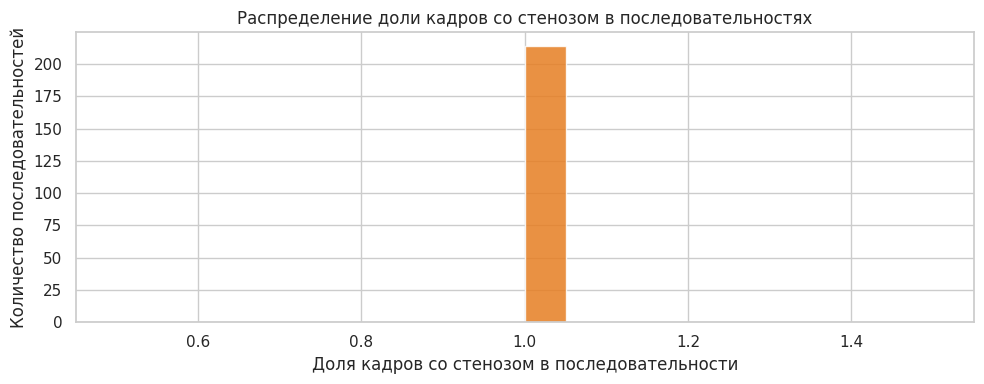


Количество bbox-ов на кадр (среди кадров со стенозом):
  1 bbox: 8323 кадров (100.0%)


In [11]:
# Распределение доли кадров со стенозом в последовательностях
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_stats['stenosis_ratio'].values, bins=20, color='#e67e22', edgecolor='white', alpha=0.85)
ax.set_xlabel('Доля кадров со стенозом в последовательности')
ax.set_ylabel('Количество последовательностей')
ax.set_title('Распределение доли кадров со стенозом в последовательностях')
plt.tight_layout()
plt.show()

# Количество bbox-ов на кадр (среди кадров со стенозом)
stenosis_frames = df[df['has_stenosis']]
bbox_counts = stenosis_frames['num_bboxes'].value_counts().sort_index()
print(f"\nКоличество bbox-ов на кадр (среди кадров со стенозом):")
for n, count in bbox_counts.items():
    print(f"  {n} bbox: {count} кадров ({count/len(stenosis_frames)*100:.1f}%)")

## 8. Примеры кадров из нескольких последовательностей

Показаны первые кадры из нескольких случайных последовательностей (со стенозом и без). Красные прямоугольники — размеченные bbox стенозов.

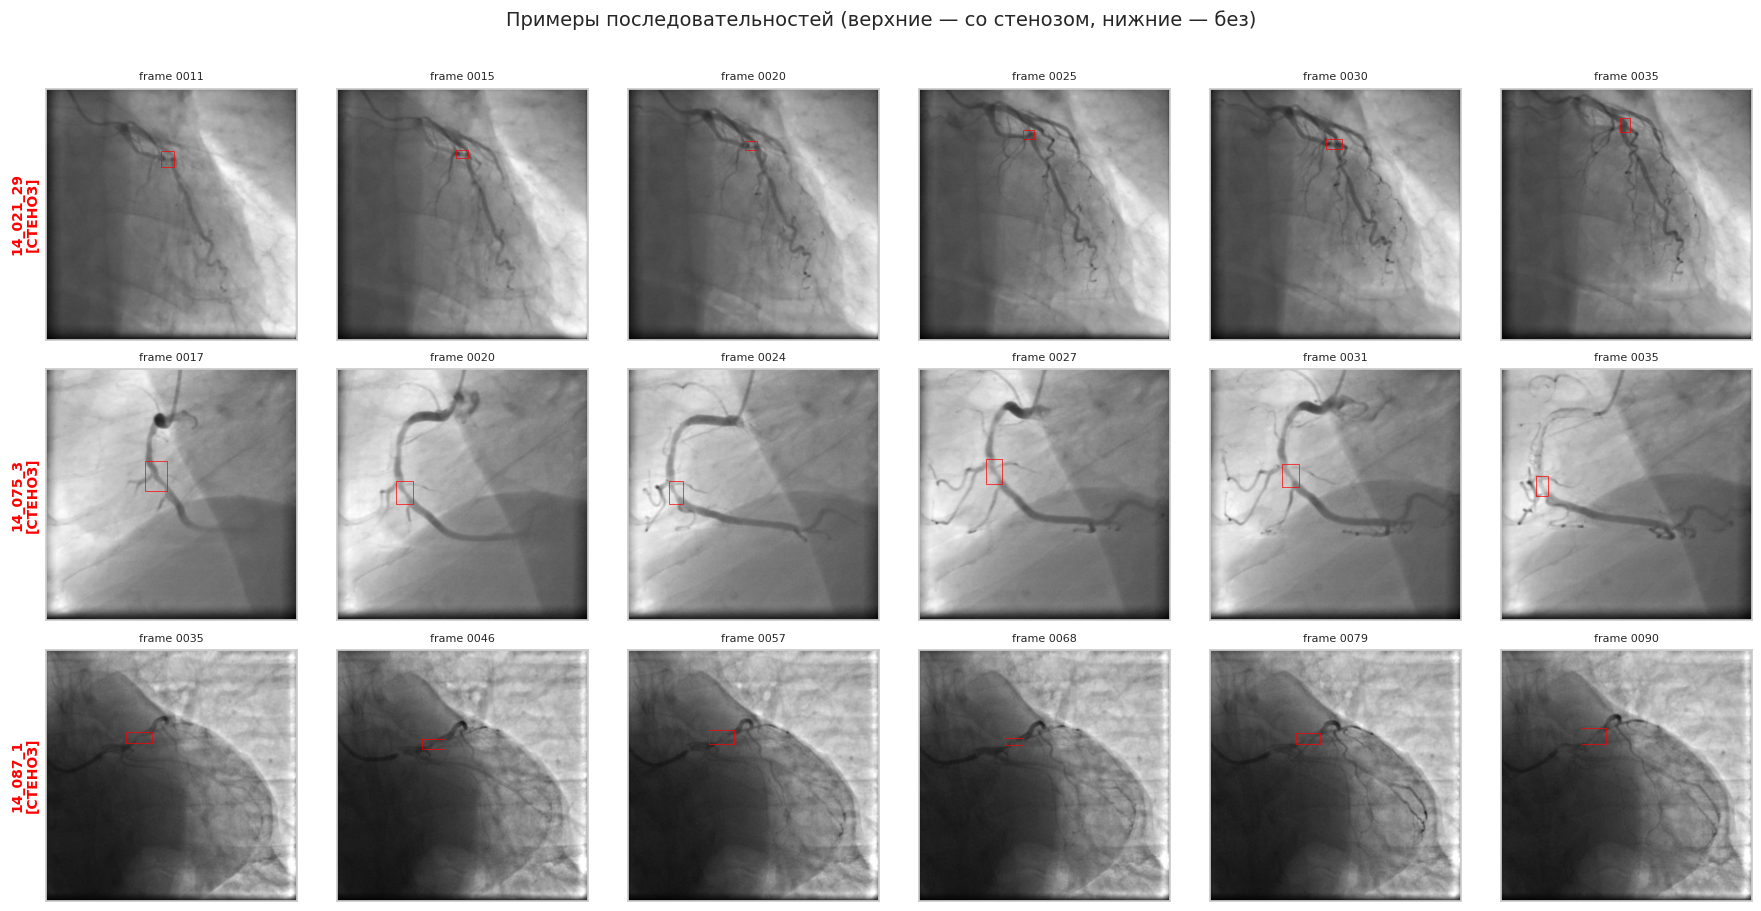

In [12]:
from PIL import Image
import numpy as np
import random

random.seed(4122)

# Выберем 3 последовательности со стенозом и 3 без
seqs_with = seq_stats[seq_stats['has_any_stenosis']]['sequence_id'].tolist()
seqs_without = seq_stats[~seq_stats['has_any_stenosis']]['sequence_id'].tolist()

sample_with = random.sample(seqs_with, min(3, len(seqs_with)))
sample_without = random.sample(seqs_without, min(3, len(seqs_without)))
sample_seqs = sample_with + sample_without

N_FRAMES_PER_SEQ = 6  # сколько кадров показать из каждой последовательности
n_rows = len(sample_seqs)

fig, axes = plt.subplots(n_rows, N_FRAMES_PER_SEQ, figsize=(N_FRAMES_PER_SEQ * 3, n_rows * 3))

for row_idx, seq_id in enumerate(sample_seqs):
    seq_df = df[df['sequence_id'] == seq_id].sort_values('frame')
    # Равномерно выбираем кадры
    indices = np.linspace(0, len(seq_df) - 1, N_FRAMES_PER_SEQ, dtype=int)
    selected = seq_df.iloc[indices]
    
    has_st = seq_id in seqs_with
    label_text = "СТЕНОЗ" if has_st else "НОРМА"
    color = 'red' if has_st else 'green'
    
    for col_idx, (_, frame_row) in enumerate(selected.iterrows()):
        ax = axes[row_idx, col_idx]
        img_path = IMAGES_DIR / frame_row['image_name']
        img = Image.open(img_path)
        ax.imshow(np.array(img), cmap='gray')
        
        # Нарисовать bbox если есть стеноз на этом кадре
        if frame_row['has_stenosis']:
            label_name = frame_row['image_name'].replace('.jpg', '.txt').replace('.png', '.txt')
            label_path = LABELS_DIR / label_name
            content = label_path.read_text().strip()
            w_img, h_img = img.size
            for line in content.splitlines():
                parts = line.split()
                cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = (cx - bw / 2) * w_img
                y1 = (cy - bh / 2) * h_img
                rect_w = bw * w_img
                rect_h = bh * h_img
                rect = plt.Rectangle((x1, y1), rect_w, rect_h, linewidth=0.5, edgecolor='red', facecolor='none')
                ax.add_patch(rect)
        
        ax.set_xticks([])
        ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(f"{seq_id}\n[{label_text}]", fontsize=10, color=color, fontweight='bold')
        ax.set_title(f"frame {frame_row['frame']}", fontsize=8)

plt.suptitle('Примеры последовательностей (верхние — со стенозом, нижние — без)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()